In [23]:
from pathlib import Path
from urllib import request

from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

from ppxf.ppxf import ppxf, robust_sigma
import ppxf.ppxf_util as util
import ppxf.sps_util as lib

import pandas as pd

In [24]:
wv, flux = np.loadtxt('Spectra1s_4', unpack = True)
z = 0.0238 
wv_rf = wv/(1+z)
flux_rf = flux*(1+z)

In [25]:
# sps_name = 'fsps'
# sps_name = 'galaxev'
sps_name = 'emiles'
# sps_name = 'xsl'

In [26]:
ppxf_dir = Path(lib.__file__).parent
basename = f"spectra_{sps_name}_9.0.npz"
filename = ppxf_dir / 'sps_models' / basename
if not filename.is_file():
    url = "https://raw.githubusercontent.com/micappe/ppxf_data/main/" + basename
    request.urlretrieve(url, filename)

In [27]:
c = 299792.458  # speed of light in km/s
velscale = np.min(c*np.diff(np.log(wv_rf))) #velocity scale to quantify the galaxy velocity dispersion
flux_rf_rebin, wv_rf_rebin, velscale = util.log_rebin(wv_rf, flux_rf, velscale = velscale) #We need to rebin the flux and the other things to work with the code
galaxy = flux_rf_rebin/np.median(flux_rf_rebin) #Normalization

In [28]:
velscale

63.72589802401001

63.72589802401001

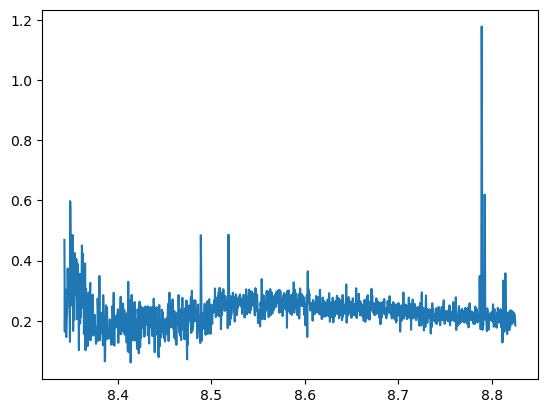

In [29]:
%matplotlib inline
plt.plot(wv_rf_rebin, flux_rf_rebin)
np.mean(c*np.diff((wv_rf_rebin)))

In [30]:
R = 1000 #risoluzione FORS2
fwhm_gal = (wv_rf/R)/(1+z) # CONTROLLARE QUESTA COSA
print(fwhm_gal)

[4.1031079  4.10451989 4.10593188 ... 6.64045302 6.64186501 6.643277  ]


In [31]:
fwhm_gal_dic = {"lam": wv_rf, "fwhm": fwhm_gal}
sps = lib.sps_lib(filename, velscale, fwhm_gal_dic)

(3197, 150)

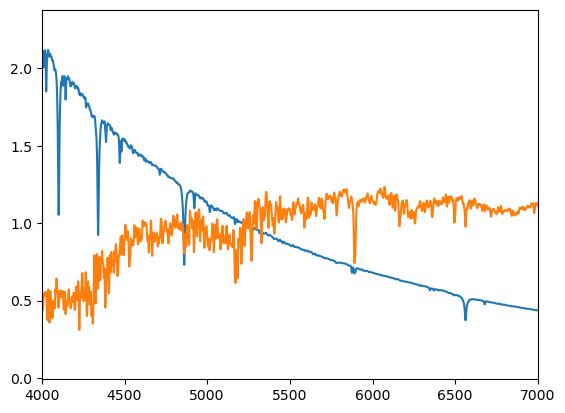

In [32]:
reg_dim = sps.templates.shape[1:]
stars_templates = sps.templates.reshape(sps.templates.shape[0], -1)
ln_lam_pop_stars = sps.ln_lam_temp
mask = (np.exp(ln_lam_pop_stars) > (np.min(wv_rf)-500))*(np.exp(ln_lam_pop_stars) < (np.max(wv_rf)+500))
stars_templates = stars_templates[mask, :]
stars_templates /= np.median(stars_templates, axis=0)
ln_lam_pop_stars = ln_lam_pop_stars[mask]

plt.plot(np.exp(ln_lam_pop_stars), stars_templates[:, 0])
plt.plot(np.exp(ln_lam_pop_stars), stars_templates[:, -1])
plt.xlim(4000, 7000)
stars_templates.shape

In [33]:
np.mean(c*np.diff((ln_lam_pop_stars)))

63.72589802401001

In [34]:
stars_templates.shape

(3197, 150)

In [35]:
np.mean(stars_templates, axis = 0)

array([1.10898285, 1.08360962, 1.09017428, 1.09464419, 1.07939221,
       1.09915411, 1.10137737, 1.0822638 , 1.08601919, 1.08897678,
       1.077777  , 1.09506324, 1.10149057, 1.07900302, 1.08425135,
       1.08299716, 1.07679942, 1.08789784, 1.04930333, 1.05065203,
       1.07203091, 1.0858804 , 1.08261809, 1.08658106, 1.04387738,
       1.03957246, 1.06941656, 1.07609443, 1.08220689, 1.08472903,
       1.03980424, 1.03302717, 1.06784896, 1.0677345 , 1.07610127,
       1.07695244, 1.04249277, 1.03686966, 1.06092003, 1.06298708,
       1.0737808 , 1.07071008, 1.04580539, 1.0426212 , 1.05102044,
       1.05893342, 1.06980517, 1.06122754, 1.04095935, 1.04413976,
       1.04883257, 1.05588558, 1.05626558, 1.04899079, 1.04011005,
       1.03508475, 1.04521923, 1.04848728, 1.03642645, 1.01848222,
       1.03322001, 1.0294235 , 1.03594441, 1.02773826, 1.00858147,
       1.00101467, 1.02514048, 1.02078306, 1.01955068, 1.00910956,
       0.99187107, 0.97789091, 1.01343024, 1.01027807, 1.00882

In [36]:
tie_balmer = False 
limit_doublets = True

lam_range_gal = np.array([np.min(wv_rf), np.max(wv_rf)])
gas_templates, gas_names, line_wave = util.emission_lines(
    ln_lam_pop_stars, lam_range_gal, fwhm_gal_dic, tie_balmer=tie_balmer,
    limit_doublets=limit_doublets)

Emission lines included in gas templates:
['Hgamma' 'Hbeta' 'Halpha' '[SII]6731_d1' '[SII]6731_d2' 'HeII4687'
 'HeI5876' '[OIII]5007_d' '[OI]6300_d' '[NII]6583_d']


In [37]:
templates = np.column_stack([stars_templates, gas_templates])
start = [20, 180.] 

In [38]:
n_temps = stars_templates.shape[1]
n_forbidden = np.sum(["[" in a for a in gas_names])  # forbidden lines contain "[*]"
n_balmer = len(gas_names) - n_forbidden

In [39]:
component = [0]*n_temps + [1]*n_balmer + [2]*n_forbidden #When fitting more than one kinematic component, this keyword should contain the component number of each input template. 
                                                         #In principle, every template can belong to a different kinematic component.

gas_component = np.array(component) > 0  # gas_component=True for gas templates
                                         #Boolean vector, of the same size as component, set to True where the given component describes a gas emission line. 
                                         #If given, pPXF provides the pp.gas_flux and pp.gas_flux_error in output.

In [40]:
moments = [2, 2, 2]
start = [start, start, start]
gas_reddening = 0 if tie_balmer else None

In [41]:
pp = ppxf(templates, galaxy, 0.1*np.ones_like(wv_rf_rebin), velscale, start, moments=moments,     #We put what we had set here to do the ppxf procedure
          degree=7, mdegree=-1, lam=np.exp(wv_rf_rebin), lam_temp=np.exp(ln_lam_pop_stars), component=component,
          gas_component=gas_component, gas_names=gas_names,
          gas_reddening=gas_reddening)
#print(f"Elapsed time in pPXF: {(clock() - t):.2f}")

 Best Fit:       Vel     sigma
 comp.  0:       -93        42
 comp.  1:       -59         1
 comp.  2:       -51         1
chi2/DOF: 2.743; DOF: 2262; degree = 7; mdegree = 0
method = capfit; Jac calls: 7; Func calls: 51; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 13/160
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
gas_component           name        flux       err      V     sig
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Comp:  1                Hgamma      3.021      0.26     -59     1
Comp:  1                 Hbeta      6.555      0.26     -59     1
Comp:  1                Halpha      16.68      0.26     -59     1
Comp:  1          [SII]6731_d1      2.278      0.67     -59     1
Comp:  1          [SII]6731_d2      2.121      0.71     -59     1
Comp:  2              HeII4687      0.000      0.26     -51     1
Comp:  2               HeI5876     0.4543      0.26     -51     1
Comp:  2          [OIII]5007_d      5.329      0

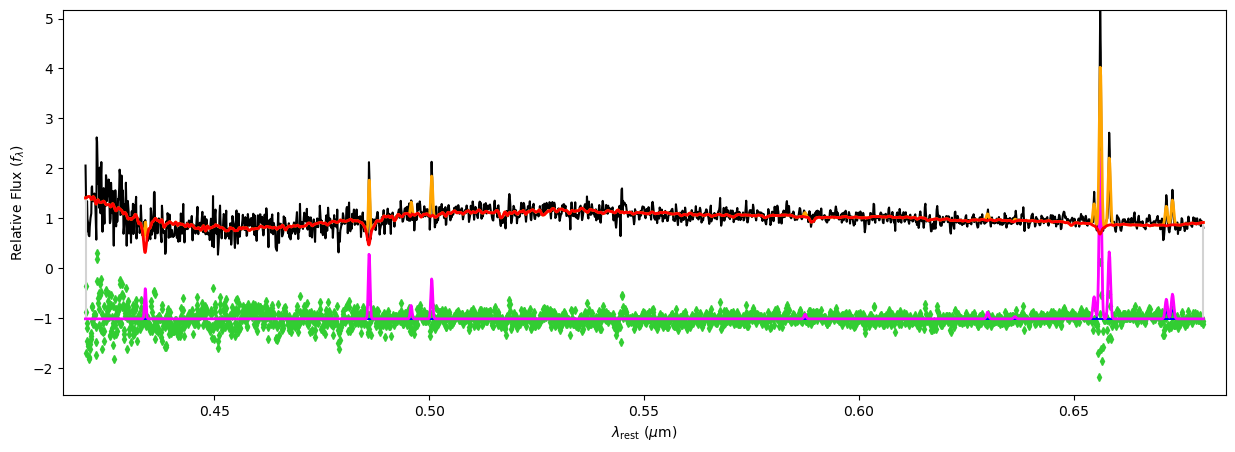

In [42]:
plt.figure(figsize=(15, 5))
pp.plot()

In [43]:
d1 = {'Name': gas_names, 'Flux': pp.gas_flux, 'Error flux': pp.gas_flux_error}
df1 = pd.DataFrame(data=d1)
df1.to_csv("Spectrum1_4_gas.csv", index= False)

d2 = {'Component': [0, 1, 2], 'Vel': [pp.sol[0][0], pp.sol[1][0], pp.sol[2][0]], 'Sigma': [pp.sol[0][1], pp.sol[1][1], pp.sol[2][1]]}
df2 = pd.DataFrame(data=d2)
df2.to_csv("Spectrum1_4_kin.csv", index= False)

In [44]:
read = pd.read_csv("Spectrum1_4_gas.csv")
read

,Name,Flux,Error flux
0,Hgamma,3.021402,0.264431
1,Hbeta,6.555243,0.264431
2,Halpha,16.684352,0.264431
3,[SII]6731_d1,2.277586,0.671635
4,[SII]6731_d2,2.120530,0.709503
5,HeII4687,0.000000,0.264431
6,HeI5876,0.454298,0.264431
7,[OIII]5007_d,5.328697,0.333979
8,[OI]6300_d,0.887435,0.333979
9,[NII]6583_d,8.854551,0.333979
